(2048, 1452, 3)


(np.float64(-0.5), np.float64(1451.5), np.float64(2047.5), np.float64(-0.5))

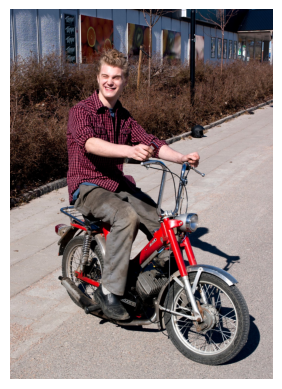

In [107]:
"""
Apply convolution on a custom image and show the results. 
Then, apply max-pooling, depth-wise pooling, and average pooling on the images from the previous step and show the results.
"""

import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(123)#got so boring images from the random weigths so changed this

img = plt.imread(os.path.join("C:\\Users\\nisse\\Skola\\DIL700\\2strokecasanova.jpg")) /255.0 # loading and normalizing
print(img.shape)

plt.imshow(img)
plt.axis("off")





(1, 2048, 1452, 3)


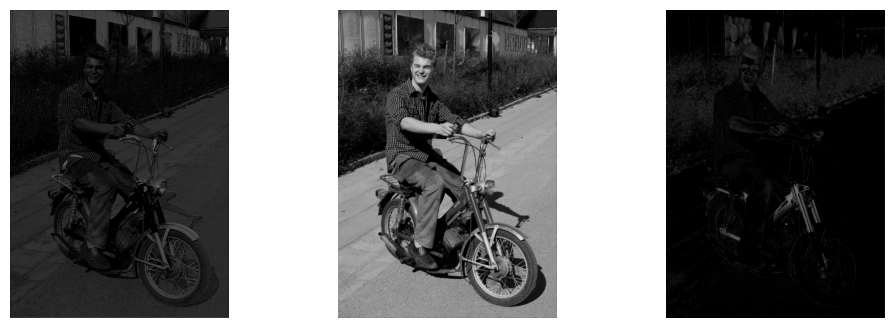

In [108]:
conv_layer = tf.keras.layers.Conv2D(filters=3, kernel_size=(3, 3), activation="relu", padding="same")

y = conv_layer(tf.expand_dims(img, axis=0)) # adding batch dimension
print(y.shape)

img1 = y[0, :, :, 0]
img2 = y[0, :, :, 1]    
img3 = y[0, :, :, 2]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(y[0, :, :, i], cmap="gray")
    plt.axis("off")

(1, 682, 484, 3)


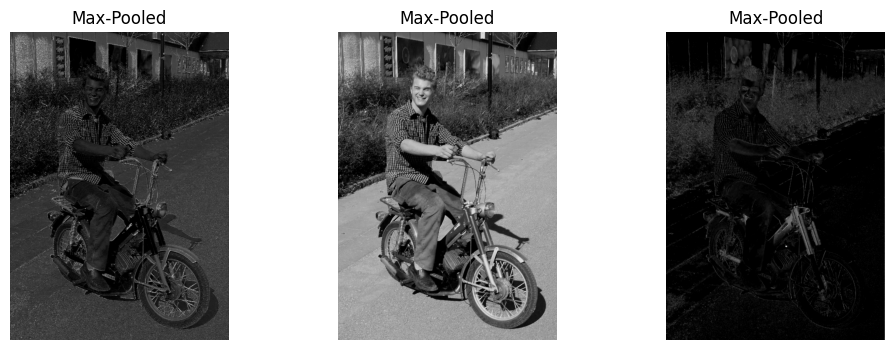

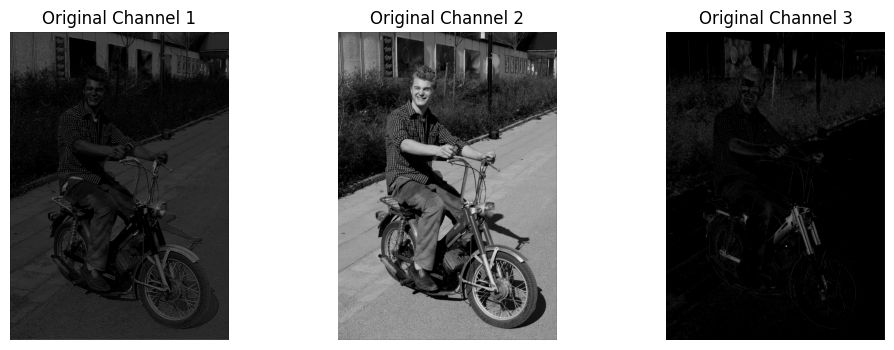

In [109]:
# Max-pooling
max_pool = tf.keras.layers.MaxPooling2D(pool_size=(3, 3), strides=3)
max_pooled = max_pool(y)
print(max_pooled.shape)

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(max_pooled[0, :, :, i], cmap="gray")
    plt.axis("off")
    plt.title("Max-Pooled")

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(y[0, :, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"Original Channel {i+1}")

# takes the max value in each 3x3 window and returns a smaller image.
# Stride of 3 means it moves the window 3 pixels at a time, so no overlap between windows. 
# so in this case we get a somewhat brighter image that is 1/3rd of the size



(1, 682, 484, 3)


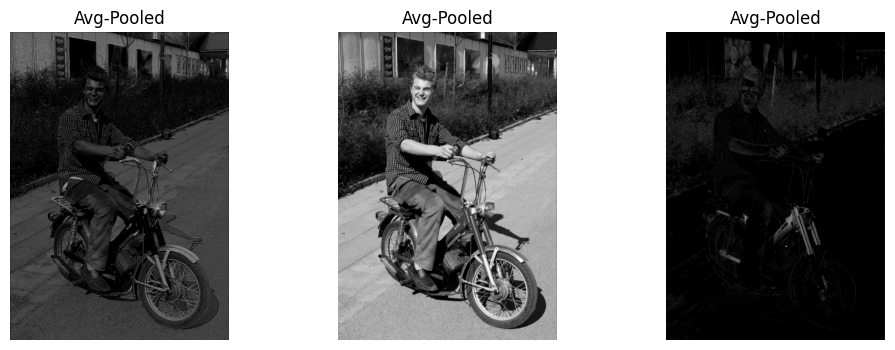

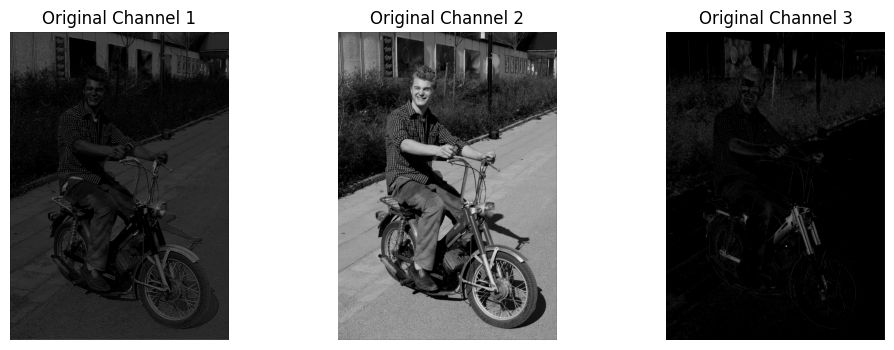

In [110]:
# Average-pooling (spatial)
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=(3, 3), strides=3)
avg_pooled = avg_pool(y)
print(avg_pooled.shape)

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(avg_pooled[0, :, :, i], cmap="gray")
    plt.axis("off")
    plt.title("Avg-Pooled")
plt.show()

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(y[0, :, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"Original Channel {i+1}")


(1, 2048, 1452, 1)


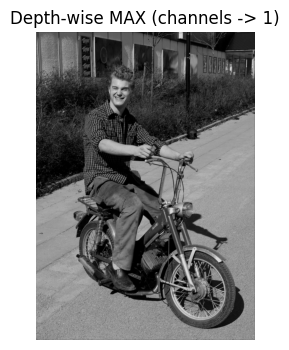

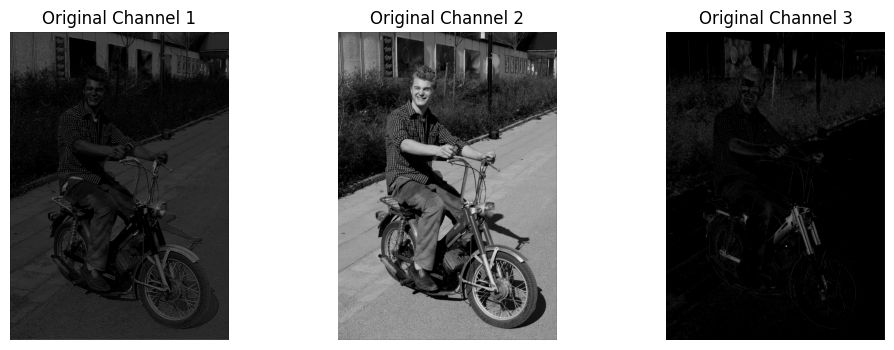

In [111]:
# Depth-wise pooling = över channel-dimensionen (djupet)
# Resultat: (1, H, W, 1)
depth_max = tf.reduce_max(y, axis=-1, keepdims=True)
print(depth_max.shape)

plt.figure(figsize=(6, 4))
plt.imshow(depth_max[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.title("Depth-wise MAX (channels -> 1)")
plt.show()

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(y[0, :, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"Original Channel {i+1}")